# Логистическая регрессия

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import time
import seaborn as sns
from tqdm import tqdm
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.stats import mode

## Имплементация


Алгоритм логистической регрессии работает путем реализации линейного уравнения с независимыми или объясняющими переменными для прогнозирования значения ответа. Например, мы рассмотрим пример количества изученных часов и вероятности сдачи экзамена. Здесь количество изученных часов является объяснительной переменной, и она обозначена $x_1$. Вероятность сдачи экзамена является переменной ответа или целевой, и она обозначена $z$.


Если у нас есть одна объяснительная переменная $x_1$ и одна переменная ответа $z$, то линейное уравнение будет предоставлено математически со следующим уравнением:

 $z = β_0 + β_1x_1$

Здесь коэффициенты $β_0$ и $β_1$ являются параметрами модели.


Если есть несколько объяснительных переменных, то вышеуказанное уравнение может быть расширено на

$z = β_0+ β_1x_1+ β_2x_2+ ... + β_nx_n$

Здесь коэффициенты $β_0, β_1, β_2, ...$ и $β_N$ являются параметрами модели.

## Сигмоида

Формула сигмоиды: $σ(x) = \dfrac{1}{1 + e^{-x}}$

Это прогнозируемое значение ответа, обозначаемое $z$, с помощью сигмоиды преобразуется в значение вероятности, которое лежит между 0 и 1.

В машинном обучении сигмоида используется для перевода прогнозов в вероятности. Сигмоида имеет кривую в форме S. Это также называется сигмоидальной кривой.

Сигмоида - это особый случай логистической функции. Это дано следующей математической формулой.

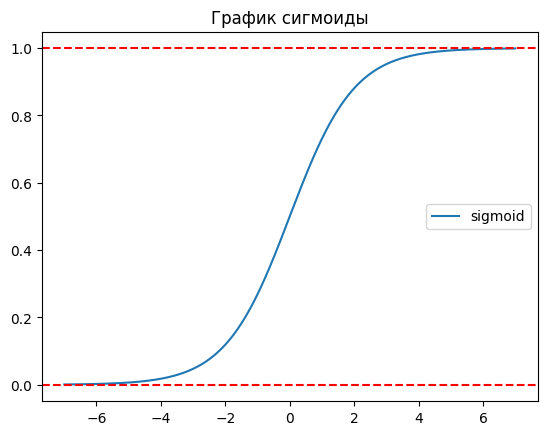

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


x = np.linspace(-7, 7, 100000)
plt.plot(x, sigmoid(x), label='sigmoid')
plt.axhline(y=0, linestyle='--', color='r')
plt.axhline(y=1, linestyle='--', color='r')
plt.legend()
plt.title('График сигмоиды');

## Пороговое значение

Сигмоида возвращает значение вероятности от 0 до 1. Это значение вероятности затем отображается с дискретным классом, который является либо «0», либо «1». Чтобы отобразить это значение вероятности с дискретным классом , мы выбираем пороговое значение. Выше этого порогового значения мы сопоставляем значения вероятности в класс 1 и ниже, которые мы сопоставляем значения в класс 0.

Математически это может быть выражено следующим образом:-

$p \geqslant 0,5 =>$ класс = 1

$p < 0.5 =>$ класс = 0

Как правило, граница принятия решений установлена ​​на 0,5.

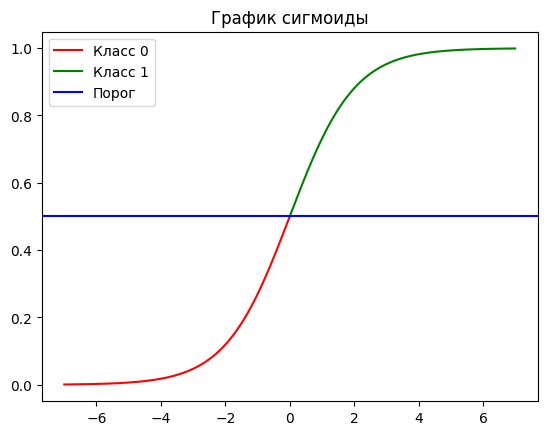

In [ ]:
x = np.linspace(-7, 7, 100000)
plt.plot(x[:50000], sigmoid(x[:50000]), label='Класс 0', color='r')
plt.plot(x[50000:], sigmoid(x[50000:]), label='Класс 1', color='g')
plt.axhline(y=0.5, color='b', label='Порог')
plt.legend()
plt.title('График сигмоиды');

## Предположения логистической регрессии


Модель логистической регрессии требует нескольких ключевых предположений:

1. Зависимая переменная должна быть бинарной, обычно её кодируют как ноль и один (но можно и решать задачу многоклассовой классификации)

2. Независимость наблюдений друг от друга

3. Отсутствие мультиколлинеарности

4. Достаточный размер выборки (хотя бы тридцать наблюдений)

5. Отсутствие выбросов.

## Импортируем датасет

In [ ]:
df = pd.read_csv('/content/healthcare-dataset-stroke-data.csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
df["stroke"].unique()

array([1, 0])

**Задание 1**
Удалите столбец, который явно не несет информации об объекте. В качестве ответа запишите в переменную useless_col название этой колонки.

In [ ]:
answer_lst = []
useless_col = 'id'
df = df.drop(columns=useless_col)

print(df.shape)

answer_lst.append(useless_col)

(5110, 11)


### Типы признаков

Поработаем отдельно с числовыми и категориальными признаками

## Категориальные признаки


Категориальными признаками мы называем такие признаки, множество значений которых конечно (делится на разные категории).

**Задание 2** Составьте список категориальных переменных и запишите в переменную categorical (целевую переменную не записывайте)

In [ ]:
categorical = ['gender', 'ever_married', 'work_type', 'Residence_type','smoking_status', 'hypertension', 'heart_disease']

answer_lst.append(categorical)

### Частота категорий в категориальных признаках


Посмотрим как часто встречается каждая категория во всех категориальных признаках

In [ ]:
for i in categorical:
  print(f"\nЧастота категорий в столбце {i}: \n")
  print(df[i].value_counts())


Частота категорий в столбце gender: 

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

Частота категорий в столбце ever_married: 

ever_married
Yes    3353
No     1757
Name: count, dtype: int64

Частота категорий в столбце work_type: 

work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

Частота категорий в столбце Residence_type: 

Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

Частота категорий в столбце smoking_status: 

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

Частота категорий в столбце hypertension: 

hypertension
0    4612
1     498
Name: count, dtype: int64

Частота категорий в столбце heart_disease: 

heart_disease
0    4834
1     276
Name: count, dtype: int64


### Количество меток

Посмотрим сколько различных значений встречается в каждом категориальном признаке

In [ ]:
for i in categorical:
  print(f"\nКакие различные значения есть в столбце {i}: \n")
  print(df[i].unique())


Какие различные значения есть в столбце gender: 

['Male' 'Female' 'Other']

Какие различные значения есть в столбце ever_married: 

['Yes' 'No']

Какие различные значения есть в столбце work_type: 

['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']

Какие различные значения есть в столбце Residence_type: 

['Urban' 'Rural']

Какие различные значения есть в столбце smoking_status: 

['formerly smoked' 'never smoked' 'smokes' 'Unknown']

Какие различные значения есть в столбце hypertension: 

[0 1]

Какие различные значения есть в столбце heart_disease: 

[1 0]


### Пропуски

Проверим пропуски в категориальных признаках

In [ ]:
for i in categorical:
  print(f"\nПропуски в столбце {i}:")
  print(df[i].isna().sum())


Пропуски в столбце gender:
0

Пропуски в столбце ever_married:
0

Пропуски в столбце work_type:
0

Пропуски в столбце Residence_type:
0

Пропуски в столбце smoking_status:
0

Пропуски в столбце hypertension:
0

Пропуски в столбце heart_disease:
0


**Задание 3** Запишите в переменную categorical_nans количество пропусков в категориальных признаках.

In [ ]:
categorical_nans = df[categorical].isna().sum().sum()

print(categorical_nans)

answer_lst.append(categorical_nans)

0


### Заполним пропуски

При наличии пропусков заполните их самым частым значением в столбце.

In [ ]:
for column in categorical:
    most_frequent = df[column].mode()[0]
    df[column] = df[column].fillna(most_frequent)

### Делаем One-Hot Encoding

С drop_first=True

In [ ]:
from typing_extensions import final
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_data = encoder.fit_transform(df[categorical])

encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(categorical)
)

final_df = pd.concat([
    df.drop(columns=categorical),
    encoded_df
], axis=1)

final_df.head()

,age,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,hypertension_1,heart_disease_1
0,67.0,228.69,36.6,1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
1,61.0,202.21,NaN,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,80.0,105.92,32.5,1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,49.0,171.23,34.4,1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,79.0,174.12,24.0,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


**Задание 4** Введите количество столбцов нового датасета в переменную encoded_n_columns

In [ ]:
encoded_n_columns = final_df.shape[1]

print(encoded_n_columns)

answer_lst.append(encoded_n_columns)

17


## Числовые признаки

Числовыми признаками называем все признаки, множество значение которых $\in \mathbb{R}$ и не конечно.

**Задание 5**

В переменную numerical введите все числовые переменные (целевую не записывайте)

In [ ]:
numerical = ['age', 'avg_glucose_level', 'bmi']

answer_lst.append(numerical)

### Пропуски

Проверим пропуски в числовых признаках

In [ ]:
for i in numerical:
  print(f"Пропуски в числовом признаке {i}: \n")
  print(final_df[i].isna().sum())

Пропуски в числовом признаке age: 

0
Пропуски в числовом признаке avg_glucose_level: 

0
Пропуски в числовом признаке bmi: 

201


**Задание 6** Введите количество пропусков в числовых признаках в переменную numerical_nans

In [ ]:
numerical_nans = final_df[numerical].isna().sum().sum()

print(numerical_nans)

answer_lst.append(numerical_nans)

201


### Заполним пропуски

При наличии пропусков заполните пропуски в столбцах *медианой* по столбцу (можно заполнять и средним, но медиана более устойчивая статистика)

In [ ]:
for column in numerical:
    most_frequent = final_df[column].median()
    final_df[column] = final_df[column].fillna(most_frequent)

**Задание 7** Введите в переменную mean_bmi среднее значение по столбцу bmi с учетом заполненных пропусков

In [ ]:
final_df.drop_duplicates(inplace=True)
final_df.reset_index(inplace=True, drop=True)

mean_bmi = final_df['bmi'].mean()

print(mean_bmi)

answer_lst.append(mean_bmi)

28.862035225048924


### Распределение численных величин

Изобразите распределение числовых величин

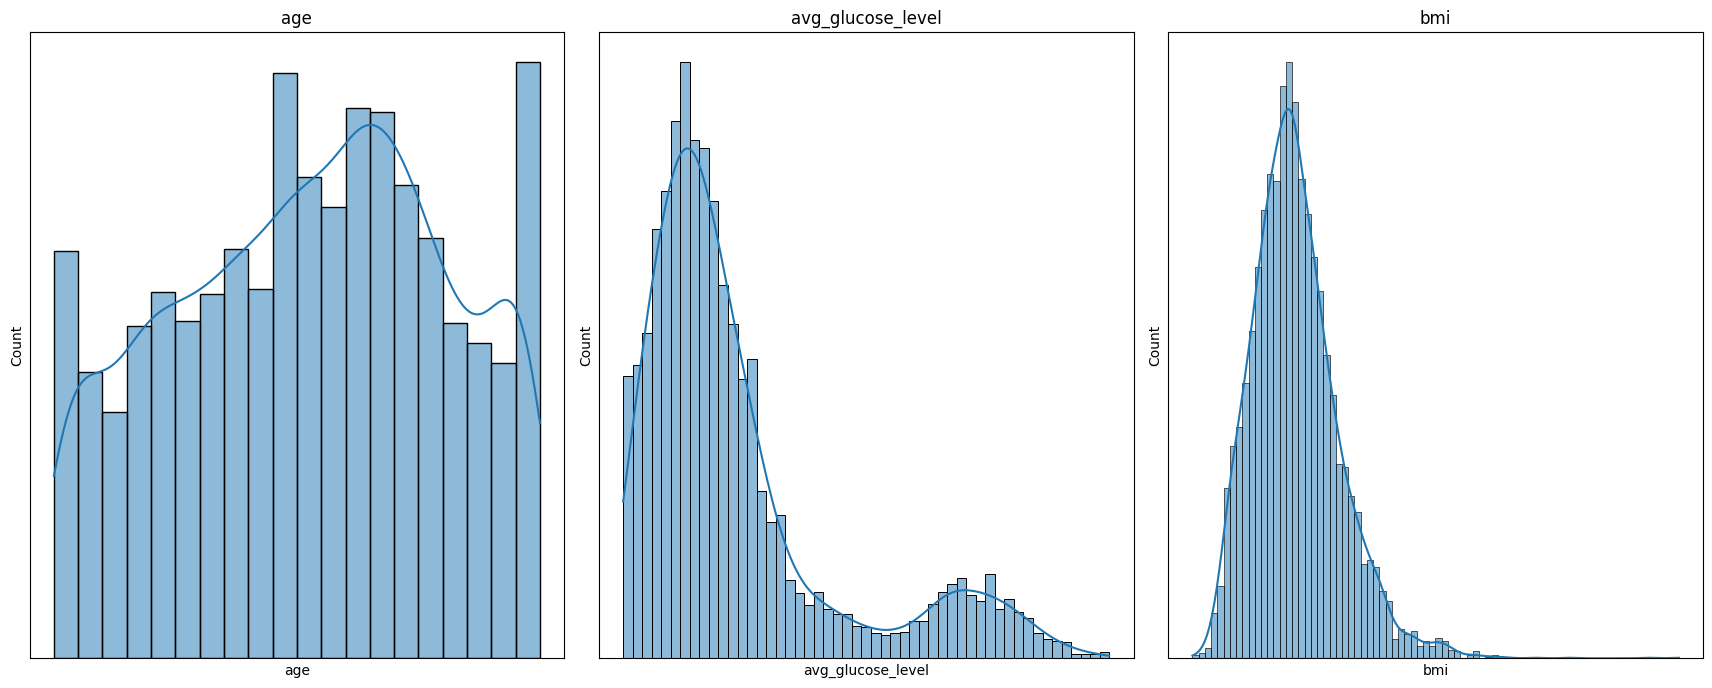

In [ ]:
columns_to_plot = final_df.drop(columns=[ 'stroke', 'gender_Male',  'gender_Other', 'ever_married_Yes', 'work_type_Never_worked',
    'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'Residence_type_Urban',
    'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes',
    'hypertension_1', 'heart_disease_1'
]).columns

plt.figure(figsize=(40, 20))
for i, column in enumerate(columns_to_plot, 1):
    plt.subplot(3, 7, i)
    sns.histplot(df[column], kde=True)
    plt.title(column)
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()

plt.show()

## Моделирование

Разделим датасет на матрицу признаков и таргет

In [ ]:
matr_priznakov = final_df.drop(columns=['stroke'])
matr_target = final_df['stroke']
# matr_target = df.drop(columns=['age', 'avg_glucose_level', 'bmi', 'gender', 'ever_married', 'work_type', 'Residence_type','smoking_status', 'hypertension', 'heart_disease'])

Посмотрим на распределение таргета

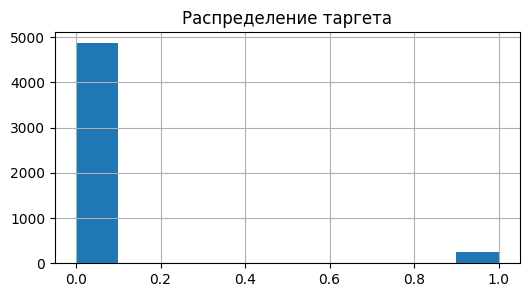

In [ ]:
plt.figure(figsize=(6, 3))
matr_target.hist()
plt.title('Распределение таргета');

Разделим данные на train и test (test_size=0.2, random_state=42)

Также установите параметр stratify=y (он разделяет данные так, чтоб объекты разных классов сохраняли свои пропорции в трейне и в тесте, то есть, если во всех данных 5% одного класса и 95% другого, то после разделения, в трейне будет 5% положительного класса среди всего трейна и в тесте будет 5% от всех данных теста), так как в таблице очень мало объектов положительного класса, и может произойти так, что в тренировочную выборку практически не попадут (или вообще не попадут) объекты положительного класса и модель обучится плохо. Также это хорошо для модели, потому что мы создаем ситуацию, что в данных, на которых модель обучалась (train) и в данных, на которых модель будет применяться (test), пропрция класса сохраняется.

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(matr_priznakov,
                                                    matr_target,
                                                    test_size=0.25,
                                                    stratify=matr_target,
                                                    random_state=42)

X_train.shape, X_test.shape

((3832, 16), (1278, 16))

Проверьте пропорции классов в исходном Y, Y_train и Y_test

In [ ]:
print(f'Процент класса 1 в y равен {matr_target.mean() * 100:.2f}%')
print(f'Процент класса 1 в y_train равен {y_train.mean() * 100:.2f}%')
print(f'Процент класса 1 в y_test равен {y_test.mean() * 100:.2f}%')

Процент класса 1 в y равен 4.87%
Процент класса 1 в y_train равен 4.88%
Процент класса 1 в y_test равен 4.85%


**Задание 8** В переменную class_1_percent введите процент класса 1 в исходных данных округленный до целого числа

In [ ]:
class_1_percent = round(matr_target.mean() * 100)

print(class_1_percent)

answer_lst.append(class_1_percent)

5


### Стандартизация численных признаков

Не забудем стандартизировать численные признаки (с помощью StandardScaler)

Обучаем скалер на X_train, применяем на X_test

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_train_scaled[numerical] = scaler.fit_transform(X_train[numerical])
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

X_test_scaled = X_test.copy()
X_test_scaled[numerical] = scaler.transform(X_test[numerical])
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(3832, 16)
(1278, 16)


Все готово! Можно приступать к обучение модели логистической регрессии.

Обучите логистическую регрессию с дефолтными параметрами.

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

Посчитайте accuracy_score

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f'accuracy = {accuracy}')

accuracy = 0.9522691705790297


Обычно метрика accuracy одна из первых приходит в голову для оценивания качества модели, ее легко считать и интерпретировать. Но в задачах с сильным дисбалансом классов, который практически всегда присутствует в медицине, высокий accuracy должен немного настораживать.

Давайте представим, что у нас есть модель a(x), которая всем объектам выдает класс 0, посчитайте ее accuracy

In [ ]:
y_train_0 = np.zeros_like(y_train)
y_train_0[0] = 1

model_a = LogisticRegression()
model_a.fit(X_train_scaled, y_train_0)

y_pred_0 = model_a.predict(X_test_scaled)
accuracy_a = accuracy_score(y_test, y_pred_0)
print(accuracy_a)

0.9514866979655712


Как видим accuracy, практически такой же, но вторая модель вообще не понимает ничего про наши данные и не знает никаких зависимостей между признаками и таргетом. Поэтому посчитаем еще другие метрики.

Посчитаем следующие метрики:
1. **Precision (точность)** - доля объектов положительного класса, среди всех объектов, которые модель отнесла к положительному классу
2. **Recall (полнота)** - доля объектов положительного класса, которые модель отнесла к положительному классу.
3. **ROC-AUC** - сложно-интерпретируемая метрика, которая в отличии от предыдущих двух не зависит от порога классификации, и помогает сразу понять, подходит ли модель вообще к задаче.
4. **F-1 score** - метрика для сравнения моделей между собой.


In [ ]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score, f1_score

Посчитайте эти три метрики для логрега и для модели, которая всем объектам выдает класс 0

In [ ]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(precision)
print(recall)
print(roc_auc)
print(f1)

print()
print()
precision_0 = precision_score(y_test, y_pred_0)
recall_score_0 = recall_score(y_test, y_pred_0)
roc_auc_score_0 = roc_auc_score(y_test, y_pred_0)
f1_score_0 = f1_score(y_test, y_pred_0)

print(precision_0)
print(recall_score_0)
print(roc_auc_score_0)
print(f1_score_0)

1.0
0.016129032258064516
0.5080645161290323
0.031746031746031744


0.0
0.0
0.5
0.0


**Задание 9** Введите в переменную roc_auc_0 значение roc_auc для модели выдающей всем объектам класс 0.

In [ ]:
roc_auc_0 = roc_auc_score(y_test, y_pred_0)

print(roc_auc_0)

answer_lst.append(roc_auc_0)

0.5


Тут уже видим, что первая модель получше второй (что логично), но в целом к первой модели есть вопросы. А именно - precision = 1. Слишком подозрительно, то есть модель выдала класс 1 на 100% верно.

Давайте проверим, скольким объектам модель выдала класс 1 и сколько всего объектов 1 в тесте.

In [ ]:
count_class_1 = np.sum(y_test==1)

count_class_1_pred = np.sum(y_pred==1)

print(f"Сколько всего объектов класса 1 в тесте: {count_class_1}")

print(f"Скольким объектам модель выдала класс 1: {count_class_1_pred}")

Сколько всего объектов класса 1 в тесте: 62
Скольким объектам модель выдала класс 1: 1


**Задание 10** Введите в переменную class_1_predicted количество объектов, которые логрег классифицировал в класс 1

In [ ]:
class_1_predicted = count_class_1_pred

answer_lst.append(class_1_predicted)

Теперь понятно, почему precision равен 1, потому что модель очень мало объектов классифицировала в положительный класс.

В медицине при использовании моделей в ход идет один очень важный гиперпараметр, с помощью которого хорошо можно решать проблему дисбаланса классов.

**Введение:** модель когда обучается, она минимизирует некоторую функцию потерь, в которой по дефолту все объекты имеют одинаковый вклад. Но у нас ситуация другая, в медицине более предпочтительным классом является класс 1, и даже не так страшно ошибиться на классе 0 (лучше сказать человеку, что он болен какой-то болезнью, а потом выяснится, что не болен. Чем сказать, что он не болен, а на самом деле окажется, что он болен). Поэтому в моделях есть гиперпараметр class_weight или вес класса, то есть с каким весом мы учитываем объект конкретного класса в функцию потерь. Если у класса 1 будет стоять вес 100, а у класса 0 вес 1, то модели будет равносильно:
1. Правильно классифицировать один объект класса 1 и ошибиться на 100 объектах класса 1
2. Правильно классифицировать 100 объектов класса 0 и ошибиться на одном объекте класса 1

Поэтому она будет пытаться хорошо предсказывать класс 1 и чуть хуже предсказывать класс 0.

Если говорить в контексте метрик, нам важнее recall - захватить как можно больше объектов класса 1, а точность не так важна, потому что получится модель как в предыдущем пункте, которая классифицировала пару человек в класс 1, и почти всех остальных из класса 1 не угадала.

Обучите модель логрега с class_weight = {1:n, 0:1} где n будет от (1 до 200) и посчитайте все метрики из предыдущих пунктов. Далее постройте на одном графике все метрики.

In [ ]:
from tqdm import tqdm

Обучение модели: 100%|██████████| 200/200 [00:12<00:00, 15.87it/s]


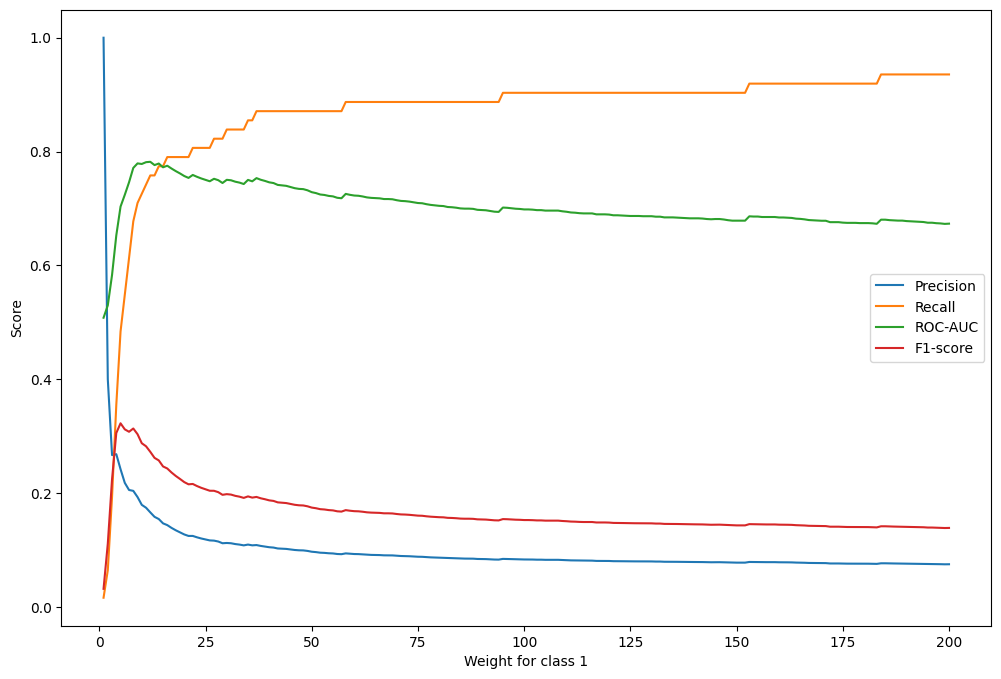

In [ ]:
values = np.arange(1, 201)
presicions = []
recalls = []
roc_aucs = []
f1_scores = []

for i in tqdm(values, desc="Обучение модели"):
  model_i = LogisticRegression(class_weight={0 : 1, 1 : i}, max_iter=1000)
  model_i.fit(X_train_scaled, y_train)
  y_pred_i = model_i.predict(X_test_scaled)

  presicions.append(precision_score(y_test, y_pred_i))
  recalls.append(recall_score(y_test, y_pred_i))
  roc_aucs.append(roc_auc_score(y_test, y_pred_i))
  f1_scores.append(f1_score(y_test, y_pred_i))

plt.figure(figsize=(12, 8))
plt.plot(values, presicions, label='Precision')
plt.plot(values, recalls, label='Recall')
plt.plot(values, roc_aucs, label='ROC-AUC')
plt.plot(values, f1_scores, label='F1-score')

plt.xlabel('Weight for class 1')
plt.ylabel('Score')
plt.legend()
plt.show()

Выберем лучшую модель с точки зрения f1_score.

**Задание 11** В переменную best_n_f1_score введите лучший вес для класса 1 с точки зрения f1_score

In [ ]:
max_f1_score = -1000000
max_n = -10
for i in range(len(values)):
  if f1_scores[i] > max_f1_score:
    max_f1_score = f1_scores[i]
    max_n = i + 1

best_n_f1_score = max_n

print(max_n)

answer_lst.append(best_n_f1_score)

#лучший показатель метрики F1 действительно находится в массиве по индексу 4, но сам вес 5
# print(max(f1_scores))
#print(f1_scores)

5


**Задание 12** В переменную best_n_roc_auc введите лучший вес для класса 1 с точки зрения roc_auc

In [ ]:
max_roc_auc_score = -1000000
max_n_roc_auc = -10
for i in range(len(values)):
  if roc_aucs[i] > max_roc_auc_score:
    max_roc_auc_score = roc_aucs[i]
    max_n_roc_auc = i + 1

best_n_roc_auc = max_n_roc_auc

print(best_n_roc_auc)

answer_lst.append(best_n_roc_auc)


#лучший показатель для roc-auc находится с массиве по индексу 11, а сам вес равен 12, здесь 13 быть не может
# print(max(roc_aucs))
# print(roc_aucs)

12


Обучите логрег с лучшим весом для класса 1 по f1_score и по roc_auc и посчитайте все метрики.

In [ ]:
print("Метрики для моделей с максимальным весом по f1:")
model_f1 = LogisticRegression(class_weight={0 : 1, 1 : 5}, max_iter=1000)
model_f1.fit(X_train_scaled, y_train)
y_pred_f1 = model_f1.predict(X_test_scaled)

precision_f1 = precision_score(y_test, y_pred_f1)
recall_f1 = recall_score(y_test, y_pred_f1)
roc_auc_f1 = roc_auc_score(y_test, y_pred_f1)
f1_f1 = f1_score(y_test, y_pred_f1)

print(precision_f1)
print(recall_f1)
print(roc_auc_f1)
print(f1_f1)


print()
print()

print("Метрики для моделей с максимальным весом по roc_auc:")
model_roc_auc = LogisticRegression(class_weight={0 : 1, 1 : 12}, max_iter=1000)
model_roc_auc.fit(X_train_scaled, y_train)
y_pred_roc_auc = model_roc_auc.predict(X_test_scaled)

precision_roc_auc = precision_score(y_test, y_pred_roc_auc)
recall_roc_auc = recall_score(y_test, y_pred_roc_auc)
roc_auc_roc_auc = roc_auc_score(y_test, y_pred_roc_auc)
f1_roc_auc = f1_score(y_test, y_pred_roc_auc)

print(precision_roc_auc)
print(recall_roc_auc)
print(roc_auc_roc_auc)
print(f1_roc_auc)

Метрики для моделей с максимальным весом по f1:
0.24193548387096775
0.4838709677419355
0.7032841680814941
0.3225806451612903


Метрики для моделей с максимальным весом по roc_auc:
0.16607773851590105
0.7580645161290323
0.7819927843803056
0.27246376811594203


**Итог** f1_score ищет золотую середину по качеству для precision и recall одновременно, однако у нас предпочтение к recall, поэтому лучше модель с точки зрения roc_auc.

## Оценка


Проверьте:

1. Первое значение в answer_lst имеет тип str
2. Второе и четвертое значение в answer_lst имеют тип list

In [ ]:
import numpy as np
def grade(answer):
    res = 0

    if answer[0] == 'id':
        temp = 1
        res += temp
        print(f'За задание 1     {temp} / 1')
    else:
        print(f'За задание 10     0 / 1')
        print('Ошибка в 1 задании')

    set_1 = set(['gender', 'ever_married', 'work_type', 'Residence_type','smoking_status',
                  'hypertension', 'heart_disease'])

    temp = len(set_1 & set(answer[1])) / len(set_1 | set(answer[1]))
    res += temp
    print(f'За задание 2     {int(temp)} / 1')
    if temp != 1:
        print(f'Ошибка во втором задании')

    if answer[2] == 0:
        temp = 1
        res += temp
        print(f'За задание 3     {temp} / 1')
    else:
        print(f'За задание 10     0 / 1')
        print('Ошибка в 3 задании')

    if answer[3] == 17:
        temp = 1
        res += temp
        print(f'За задание 4     {temp} / 1')
    else:
        print(f'За задание 10     0 / 1')
        print('Ошибка в 4 задании')

    set_2 = set(['bmi', 'avg_glucose_level', 'age'])
    temp = len(set_2 & set(answer[4])) / len(set_2 | set(answer[4]))
    res += temp
    print(f'За задание 5     {int(temp)} / 1')
    if temp != 1:
        print('Ошибка в 5 задании')

    if answer[5] == 201:
        temp = 1
        res += temp
        print(f'За задание 6     {temp} / 1')
    else:
        print(f'За задание 10     0 / 1')
        print('Ошибка в 6 задании')



    if abs(float(answer[6]) - 28.862035225048924) < 0.01:
        temp = 1
        res += temp
        print(f'За задание 7     {temp} / 1')
    else:
        print('За задание 7     0 / 1')
        print('Ошибка в задании 7')

    if answer[7] == 5:
        temp = 1
        res += temp
        print(f'За задание 8     {temp} / 1')
    else:
        print(f'За задание 8     0 / 1')
        print('Ошибка в 8 задании')

    if answer[8] == 0.5:
        temp = 1
        res += temp
        print(f'За задание 9     {temp} / 1')
    else:
        print(f'За задание 9     0 / 1')
        print('Ошибка в 9 задании')

    if answer[9] == 1:
        temp = 1
        res += temp
        print(f'За задание 10     {temp} / 1')
    else:
        print(f'За задание 10     0 / 1')
        print('Ошибка в 10 задании')

    if answer[10] == 4:
        temp = 1
        res += temp
        print(f'За задание 11     {temp} / 1')
    else:
        print(f'За задание 11     0 / 1')
        print('Ошибка в 11 задании')

    if answer[11] == 13:
        temp = 1
        res += temp
        print(f'За задание 12     {temp} / 1')
    else:
        print(f'За задание 12     0 / 1')
        print('Ошибка в 12 задании')

    print()
    print()
    print()
    print(f'ИТОГОВАЯ ОЦЕНКА ЗА ДЗ {res / 12 * 10}')

grade(answer_lst)

За задание 1     1 / 1
За задание 2     1 / 1
За задание 3     1 / 1
За задание 4     1 / 1
За задание 5     1 / 1
За задание 6     1 / 1
За задание 7     1 / 1
За задание 8     1 / 1
За задание 9     1 / 1
За задание 10     1 / 1
За задание 11     0 / 1
Ошибка в 11 задании
За задание 12     0 / 1
Ошибка в 12 задании



ИТОГОВАЯ ОЦЕНКА ЗА ДЗ 8.333333333333334
